## Transformation

Two modes are available — set `MODE` in the config cell below:

| Mode | Description |
|---|---|
| `"manual"` | Uses `WARM_START` parameters directly. Fast — no search. |
| `"optimise"` | Runs `differential_evolution` to find the best parameters data-driven. Slow (~1–3 min). |

In both cases the final cell applies `best_params` to the full dataset and saves `dt_transformed.csv`.

In [1]:
import numpy as np
import pandas as pd
import sys
import warnings
warnings.filterwarnings('ignore')

sys.path.insert(0, '../src')
from transformations import apply_pipeline, objective
from tracking import log_transformation_run

from scipy.optimize import differential_evolution
from functools import partial
import mlflow

mlflow.set_tracking_uri("sqlite:///../mlruns.db")
mlflow.set_experiment("prism-mmm")

<Experiment: artifact_location='/Users/temit/Documents/Project/Ekimetrics/prism-mmm/notebooks/mlruns/1', creation_time=1777147205985, experiment_id='1', last_update_time=1777147205985, lifecycle_stage='active', name='prism-mmm', tags={}, trace_location=None, workspace='default'>

In [2]:
# ── CONFIG — change this to switch modes ──────────────────────────────────────
# "manual"   → uses WARM_START params directly, no search
# "optimise" → runs differential_evolution to find best params
MODE = "manual"

# Give this run a descriptive name so you can identify it in MLflow UI
RUN_NAME = "extra_control_variables"

# Set to True when you want to record this run in MLflow
LOG_TO_MLFLOW = False

In [3]:
df_raw          = pd.read_csv("../data/raw/dt_simulated_weekly.csv")
df_raw['DATE']  = pd.to_datetime(df_raw['DATE'])
df_raw          = df_raw.sort_values('DATE').reset_index(drop=True)
df_raw['month'] = df_raw['DATE'].dt.month_name()

MEDIA_COLS = ['tv_S', 'ooh_S', 'print_S', 'facebook_S', 'search_S']

# Precompute controls once — independent of adstock/saturation params
comp_mean = df_raw['competitor_sales_B'].mean()
comp_std  = df_raw['competitor_sales_B'].std(ddof=0)
df_raw['competitor_sales_norm'] = (df_raw['competitor_sales_B'] - comp_mean) / comp_std

# Recurring holiday dummies — additive on top of is_holiday
df_raw['is_christmas']    = df_raw['holiday'].apply(lambda h: int(any(k in str(h) for k in ['Christmas Day'])))
df_raw['is_new_year']     = df_raw['holiday'].apply(lambda h: int('New Year' in str(h)))
df_raw['is_easter_monday']= df_raw['holiday'].apply(lambda h: int('Easter Monday' in str(h)))
df_raw['is_whit_monday']  = df_raw['holiday'].apply(lambda h: int('Whit Monday'   in str(h)))
df_raw['is_labor_day']    = df_raw['holiday'].apply(lambda h: int('Labor Day'     in str(h)))

# Exact week dummies for the 6 structural outliers
for obs in [25, 57, 73, 75, 109, 123]:
    df_raw[f'is_week_{obs}'] = (df_raw.index == obs).astype(int)

event_dummies = pd.get_dummies(df_raw['events'], drop_first=False).drop(columns='na')
month_dummies = pd.get_dummies(df_raw['month'],  drop_first=True)
df_raw        = pd.concat([df_raw, event_dummies, month_dummies], axis=1)

EXACT_WEEK_COLS = [f'is_week_{obs}' for obs in [25, 57, 73, 75, 109, 123]]

CONTROL_COLS = (
    ['competitor_sales_norm', 'is_holiday',
    'is_christmas', 'is_new_year', 'is_easter_monday', 'is_whit_monday', 'is_labor_day']
    + EXACT_WEEK_COLS
    + ['event1', 'event2']
    + list(month_dummies.columns)
)

print(f"Raw data loaded: {len(df_raw)} weeks")
print(f"Control columns ({len(CONTROL_COLS)}): {CONTROL_COLS}")
print()
print("Holiday dummy counts:")
print(f"  is_christmas     : {df_raw['is_christmas'].sum()}")
print(f"  is_new_year      : {df_raw['is_new_year'].sum()}")
print(f"  is_easter_monday : {df_raw['is_easter_monday'].sum()}")
print(f"  is_whit_monday   : {df_raw['is_whit_monday'].sum()}")
print(f"  is_labor_day     : {df_raw['is_labor_day'].sum()}")

Raw data loaded: 208 weeks
Control columns (26): ['competitor_sales_norm', 'is_holiday', 'is_christmas', 'is_new_year', 'is_easter_monday', 'is_whit_monday', 'is_labor_day', 'is_week_25', 'is_week_57', 'is_week_73', 'is_week_75', 'is_week_109', 'is_week_123', 'event1', 'event2', 'August', 'December', 'February', 'January', 'July', 'June', 'March', 'May', 'November', 'October', 'September']

Holiday dummy counts:
  is_christmas     : 4
  is_new_year      : 4
  is_easter_monday : 4
  is_whit_monday   : 4
  is_labor_day     : 4


In [4]:
# Rule-of-thumb for common media genre: 
# TV c(0.3, 0.8), OOH/Print/Radio c(0.1, 0.4), digital c(0, 0.3)

# Alpha (s) controls the shape of the curve between exponential and s-shape.
# Recommended bound is c(0.5, 3). The larger the alpha, the more S-shape. The smaller, the more C-shape. 
# Gamma (k or half-saturation point) controls the inflexion point. 
# Recommended bounce is c(0.01, 1). The larger the gamma, the later the inflection point in the response curve.

ADSTOCK_COLS = [f"{c}_adstock"          for c in MEDIA_COLS]
NORM_COLS    = [f"{c}_adstock_norm"     for c in MEDIA_COLS]
SAT_COLS     = [f"{c}_adstock_norm_sat" for c in MEDIA_COLS]

# Parameter bounds: (min, max) ordered as [decay_rate, K, S] per channel
# Channel order: tv_S, ooh_S, print_S, facebook_S, search_S
BOUNDS = [
    (0.30, 0.80), (0.01, 1.00), (0.5, 3.0),   # tv_S
    (0.10, 0.40), (0.01, 1.00), (0.5, 3.0),   # ooh_S
    (0.10, 0.40), (0.01, 1.00), (0.5, 3.0),   # print_S
    (0.00, 0.30), (0.01, 1.00), (0.5, 3.0),   # facebook_S
    (0.00, 0.30), (0.01, 1.00), (0.5, 3.0),   # search_S
]

# BOUNDS = [
#     (0.30, 0.80), (0.01, 1.00), (0.5, 3.0),   # tv_S      -- S-shape plausible
#     (0.10, 0.40), (0.01, 1.00), (0.5, 2.0),   # ooh_S     -- mild S at most
#     (0.10, 0.40), (0.01, 1.00), (0.5, 2.0),   # print_S   -- same
#     (0.00, 0.30), (0.01, 1.00), (0.5, 1.5),   # facebook_S -- lean C-shape
#     (0.00, 0.30), (0.01, 1.00), (0.5, 1.0),   # search_S  -- C-shape only, hard cap
# ]

# Domain-knowledge defaults used as the baseline
WARM_START = np.array([
    0.60, 0.50, 2.5,   # tv_S
    0.37, 0.40, 2.0,   # ooh_S
    0.10, 0.12, 1.3,   # print_S
    0.09, 0.09, 1.1,   # facebook_S
    0.05, 0.05, 0.5,   # search_S
])

VAL_WEEKS      = 20
baseline_nrmse = objective(WARM_START, df_raw, MEDIA_COLS, ADSTOCK_COLS, NORM_COLS, SAT_COLS, CONTROL_COLS, VAL_WEEKS)
print(f"Baseline NRMSE (WARM_START): {baseline_nrmse:.4f}")

Baseline NRMSE (WARM_START): 0.0557


In [5]:
# ── Run optimisation or skip depending on MODE ────────────────────────────────
from functools import partial

obj = partial(objective,
              df_raw=df_raw,
              media_cols=MEDIA_COLS,
              adstock_cols=ADSTOCK_COLS,
              norm_cols=NORM_COLS,
              sat_cols=SAT_COLS,
              control_cols=CONTROL_COLS,
              val_weeks=VAL_WEEKS)

if MODE == "optimise":
    print("Running parameter search — typically 1–3 minutes...")
    result      = differential_evolution(obj, bounds=BOUNDS, seed=42, maxiter=300,
                                         popsize=12, tol=1e-4, init='sobol',
                                         mutation=(0.5, 1.0), recombination=0.7,
                                         polish=True, workers=1, disp=True)
    best_params = result.x
    best_nrmse  = result.fun
    print(f"\nSearch complete. Best validation NRMSE: {best_nrmse:.4f}")
else:
    best_params = WARM_START
    best_nrmse  = baseline_nrmse
    print(f"Manual mode — using WARM_START params. NRMSE: {best_nrmse:.4f}")

Manual mode — using WARM_START params. NRMSE: 0.0557


In [6]:
# ── Parameter summary & save dt_transformed.csv ───────────────────────────────
comparison = pd.DataFrame([
    {
        'channel'   : ch,
        'decay_rate': round(best_params[i * 3],     4),
        'K'         : round(best_params[i * 3 + 1], 4),
        'S'         : round(best_params[i * 3 + 2], 4),
        'source'    : MODE,
    }
    for i, ch in enumerate(MEDIA_COLS)
]).set_index('channel')

print(f"Mode           : {MODE}")
print(f"Baseline NRMSE : {baseline_nrmse:.4f}")
print(f"Final NRMSE    : {best_nrmse:.4f}")
print(f"Improvement    : {baseline_nrmse - best_nrmse:+.4f}")
print()
print("Final parameters:")
print(comparison.to_string())

df_transformed = apply_pipeline(df_raw, best_params, MEDIA_COLS, ADSTOCK_COLS, NORM_COLS)
MODEL_COLS     = ['DATE', 'revenue'] + SAT_COLS + CONTROL_COLS
df_model       = df_transformed[MODEL_COLS]
csv_path       = "../data/processed/dt_transformed.csv"
df_model.to_csv(csv_path, index=False)
print(f"\nSaved dt_transformed.csv  ({df_model.shape[0]} rows × {df_model.shape[1]} cols)")

Mode           : manual
Baseline NRMSE : 0.0557
Final NRMSE    : 0.0557
Improvement    : +0.0000

Final parameters:
            decay_rate     K    S  source
channel                                  
tv_S              0.60  0.50  2.5  manual
ooh_S             0.37  0.40  2.0  manual
print_S           0.10  0.12  1.3  manual
facebook_S        0.09  0.09  1.1  manual
search_S          0.05  0.05  0.5  manual

Saved dt_transformed.csv  (208 rows × 33 cols)


In [7]:
if LOG_TO_MLFLOW:
    with mlflow.start_run(run_name=RUN_NAME) as run:
        log_transformation_run(
            params               = best_params,
            media_cols           = MEDIA_COLS,
            mode                 = MODE,
            baseline_nrmse       = baseline_nrmse,
            best_nrmse           = best_nrmse,
            df_transformed       = df_model,
            transformed_csv_path = csv_path,
        )
        print(f"\nMLflow run logged: {run.info.run_id}")
else:
    print("Skipping MLflow logging (LOG_TO_MLFLOW = False)")

Skipping MLflow logging (LOG_TO_MLFLOW = False)


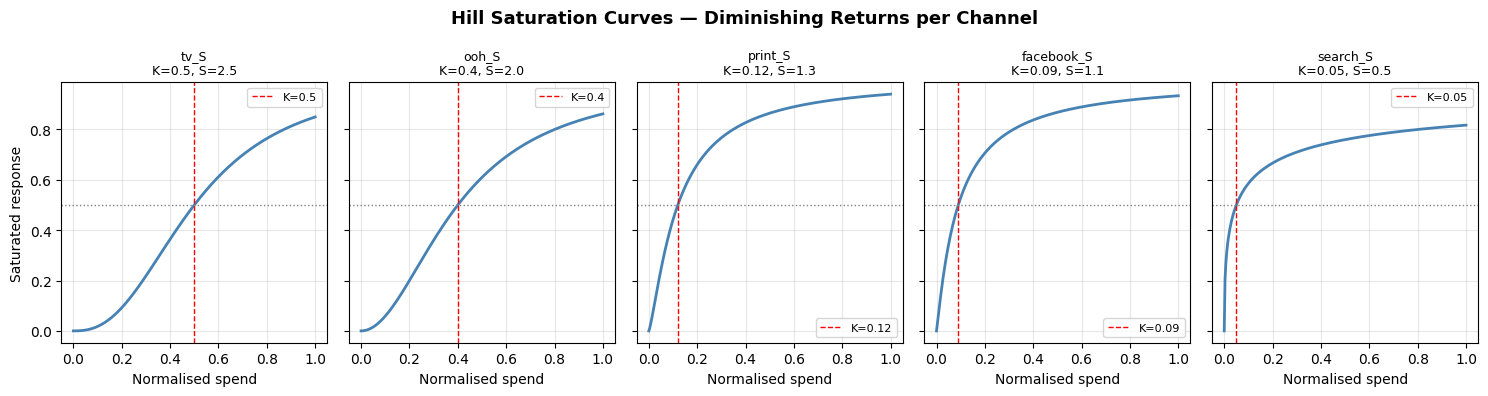

In [8]:
from transformations import hill_saturation
import matplotlib.pyplot as plt

# ── Hill saturation curves per channel ────────────────────────
x = np.linspace(0, 1, 300)

fig, axes = plt.subplots(1, len(MEDIA_COLS), figsize=(15, 4), sharey=True)

for ax, col in zip(axes, MEDIA_COLS):
    i = MEDIA_COLS.index(col)
    K = best_params[i * 3 + 1]
    S = best_params[i * 3 + 2]
    y = hill_saturation(x, K=K, S=S)
    ax.plot(x, y, linewidth=2, color='steelblue')
    ax.axvline(K, color='red', linestyle='--', linewidth=1, label=f'K={K}')
    ax.axhline(0.5, color='grey', linestyle=':', linewidth=1)
    ax.set_title(f"{col}\nK={K}, S={S}", fontsize=9)
    ax.set_xlabel('Normalised spend')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

axes[0].set_ylabel('Saturated response')
fig.suptitle('Hill Saturation Curves — Diminishing Returns per Channel', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../plots/transformation_plots/saturation_curves.png', dpi=150, bbox_inches='tight')
plt.show()